In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv('Daily_Global_Stock_Market_Indicators.csv')

df['Date'] = pd.to_datetime(df['Date'])
import warnings
warnings.filterwarnings("ignore")
df.head()

,Date,Index_Name,Country,Open,High,Low,Close,Volume,Daily_Change_Percent
0,2020-01-01,S&P 500,USA,15607.06,16277.38,15427.47,16057.78,36788921,2.89
1,2020-01-01,NASDAQ Composite,USA,7083.79,7343.64,6461.54,6641.87,22249687,-6.24
2,2020-01-01,Dow Jones,USA,26384.65,26601.25,25659.50,25941.06,4344769,-1.68
3,2020-01-01,FTSE 100,UK,8091.17,8182.45,7617.15,7774.58,44250411,-3.91
4,2020-01-01,Nikkei 225,Japan,1899.43,2044.17,1885.43,1924.21,22498555,1.30


In [6]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18270 entries, 0 to 18269
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  18270 non-null  datetime64[ns]
 1   Index_Name            18270 non-null  object        
 2   Country               18270 non-null  object        
 3   Open                  18270 non-null  float64       
 4   High                  18270 non-null  float64       
 5   Low                   18270 non-null  float64       
 6   Close                 18270 non-null  float64       
 7   Volume                18270 non-null  int64         
 8   Daily_Change_Percent  18270 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 1.3+ MB


,Date,Open,High,Low,Close,Volume,Daily_Change_Percent
count,18270,18270.000000,18270.000000,18270.000000,18270.000000,1.827000e+04,18270.000000
mean,2022-07-02 00:00:00,20442.806842,20718.693753,20166.620486,20442.378464,2.560834e+07,0.006006
min,2020-01-01 00:00:00,1000.650000,1018.520000,349.960000,622.950000,1.005194e+06,-44.320000
25%,2021-04-01 00:00:00,10743.355000,11011.495000,10471.052500,10736.957500,1.336530e+07,-1.250000
50%,2022-07-02 00:00:00,20398.855000,20685.665000,20116.395000,20394.740000,2.573716e+07,-0.010000
75%,2023-10-02 00:00:00,30208.945000,30470.575000,29938.702500,30186.750000,3.778344e+07,1.230000
max,2024-12-31 00:00:00,39990.310000,40680.180000,39985.490000,40474.780000,4.999802e+07,45.690000
std,NaN,11257.356569,11260.177506,11258.553850,11261.448439,1.414837e+07,4.534069


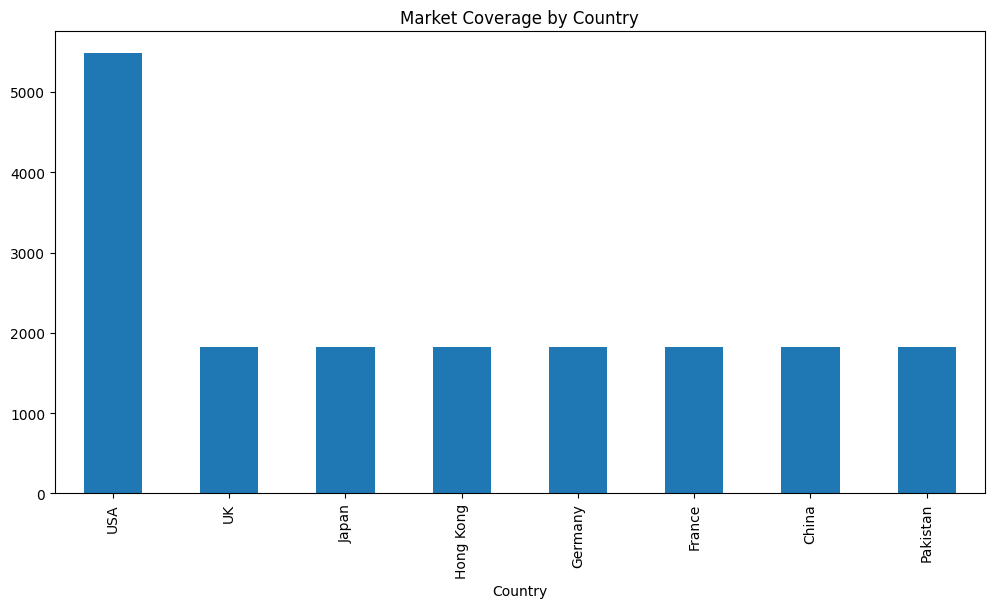

In [7]:
df['Country'].value_counts().plot(kind='bar')
plt.title("Market Coverage by Country")
plt.show()

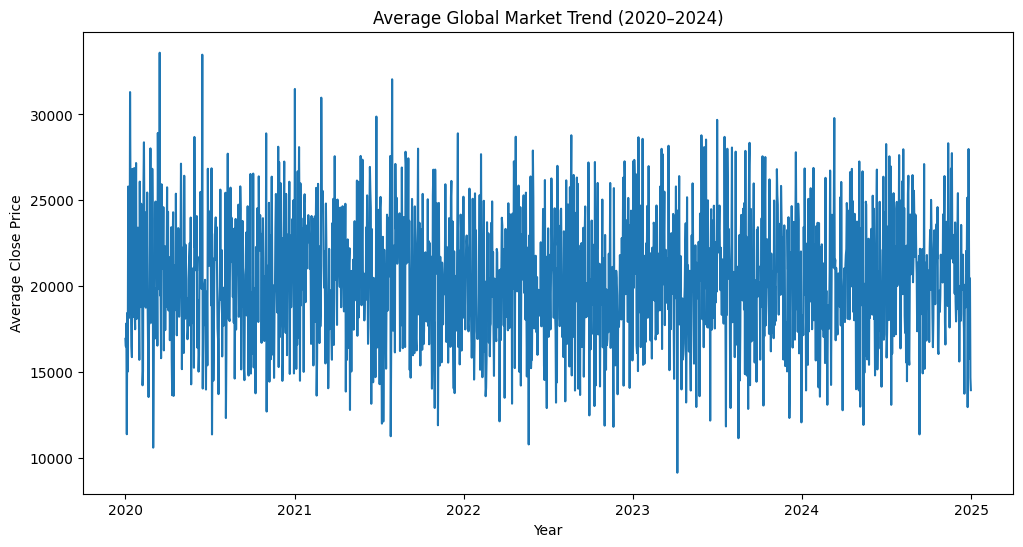

In [8]:
global_trend = df.groupby('Date')['Close'].mean()

plt.plot(global_trend)
plt.title("Average Global Market Trend (2020–2024)")
plt.xlabel("Year")
plt.ylabel("Average Close Price")
plt.show()

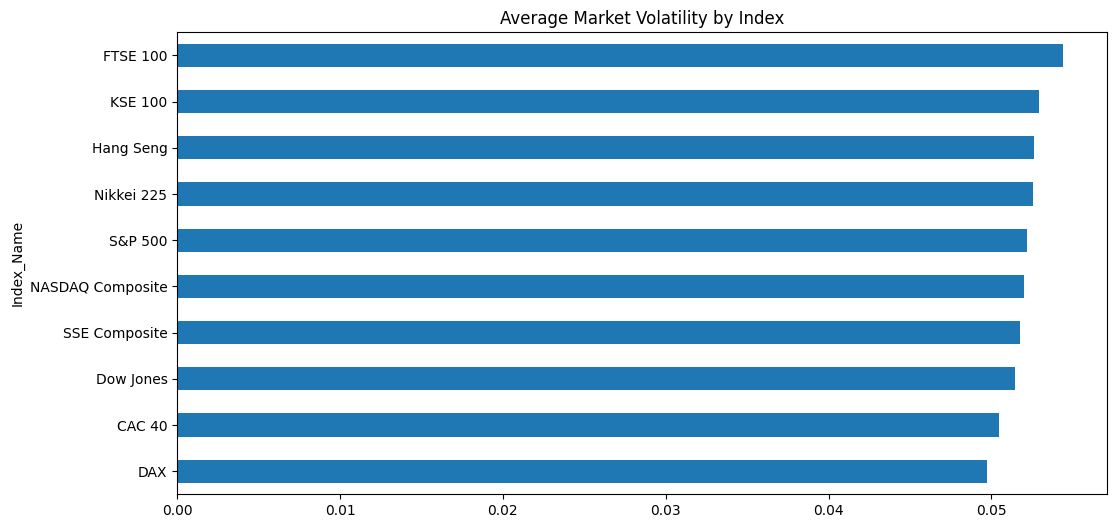

In [9]:
df['Volatility'] = (df['High'] - df['Low']) / df['Open']

volatility_by_index = df.groupby('Index_Name')['Volatility'].mean().sort_values()

volatility_by_index.plot(kind='barh')
plt.title("Average Market Volatility by Index")
plt.show()

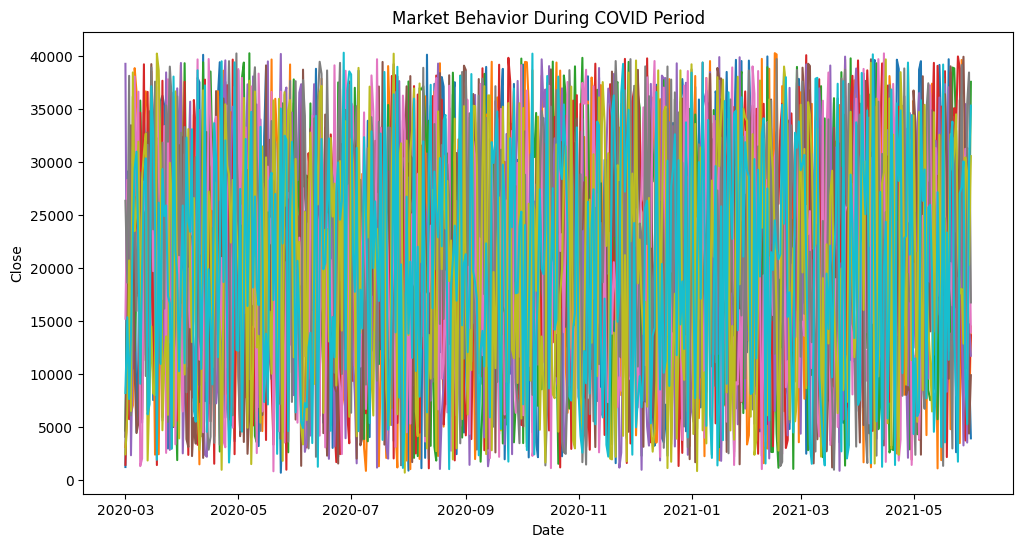

In [10]:
covid = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2021-06-01')]

sns.lineplot(data=covid, x='Date', y='Close', hue='Index_Name', legend=False)
plt.title("Market Behavior During COVID Period")
plt.show()

In [11]:
df['Daily_Return'] = df.groupby('Index_Name')['Close'].pct_change()
df['MA_7'] = df.groupby('Index_Name')['Close'].transform(lambda x: x.rolling(7).mean())
df['MA_30'] = df.groupby('Index_Name')['Close'].transform(lambda x: x.rolling(30).mean())

df.tail()

,Date,Index_Name,Country,Open,High,Low,Close,Volume,Daily_Change_Percent,Volatility,Daily_Return,MA_7,MA_30
18265,2024-12-31,Hang Seng,Hong Kong,1718.84,2027.75,1639.67,2017.82,47658304,17.39,0.225780,-0.709462,19562.595714,21152.174333
18266,2024-12-31,DAX,Germany,1513.68,1933.41,1485.06,1921.63,13456944,26.95,0.296199,-0.862259,17610.207143,19649.384333
18267,2024-12-31,CAC 40,France,8944.27,9018.54,8608.51,8737.25,36520735,-2.31,0.045843,-0.032756,20844.905714,21961.524667
18268,2024-12-31,SSE Composite,China,14674.14,15131.30,14415.31,14888.37,43850831,1.46,0.048793,-0.562091,18119.788571,20080.875667
18269,2024-12-31,KSE 100,Pakistan,11151.86,11574.65,10995.48,11387.51,15879687,2.11,0.051935,1.225736,15939.900000,20018.921000


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sample = df.dropna()

X = sample[['Open','High','Low','Volume']]
y = sample['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9998997464991306